In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

/home/hansennie/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# SVM 对 Iris 鸢尾花数据集分类
## 1. 加载数据

In [2]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f'数据集大小: {X.shape[0]} 个样本, {X.shape[1]} 个特征')
print(f'类别: {target_names}')
print(f'各类样本数: {np.bincount(y)}')

数据集大小: 150 个样本, 4 个特征
类别: ['setosa' 'versicolor' 'virginica']
各类样本数: [50 50 50]


## 2. 数据可视化

/tmp/ipykernel_75418/247681224.py:18: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75418/247681224.py:18: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75418/247681224.py:18: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75418/247681224.py:18: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75418/247681224.py:19: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.savefig('/tmp/iris_scatter.png', dpi=150)
/tmp/ipykernel_75418/247681224.py:19: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.savefig('/tmp/iris_scatter.png', dpi=150)
/tmp/ipykernel_75418/247681224.py:19: Us

/home/hansennie/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hansennie/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hansennie/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hansennie/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


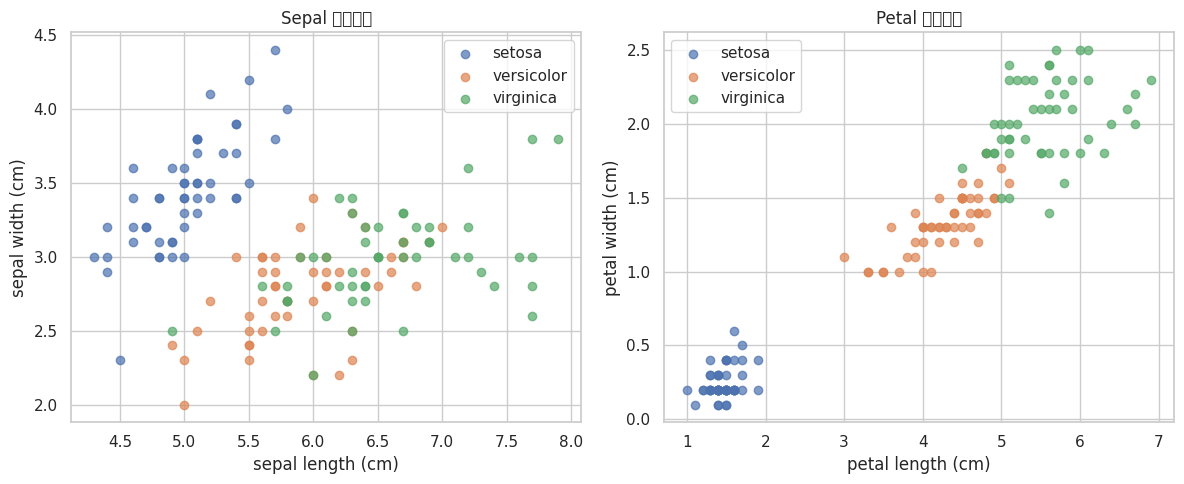

In [3]:
# 用前两个特征绘制散点图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, target_name in enumerate(target_names):
    axes[0].scatter(X[y == i, 0], X[y == i, 1], label=target_name, alpha=0.7)
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].set_title('Sepal 特征分布')
axes[0].legend()

for i, target_name in enumerate(target_names):
    axes[1].scatter(X[y == i, 2], X[y == i, 3], label=target_name, alpha=0.7)
axes[1].set_xlabel(feature_names[2])
axes[1].set_ylabel(feature_names[3])
axes[1].set_title('Petal 特征分布')
axes[1].legend()

plt.tight_layout()
plt.savefig('/tmp/iris_scatter.png', dpi=150)
plt.show()

## 3. 数据预处理与划分

In [4]:
# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集与测试集 (7:3)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f'训练集: {X_train.shape[0]}, 测试集: {X_test.shape[0]}')

训练集: 105, 测试集: 45


## 4. 训练 SVM 分类器
### 4.1 线性核 SVM

In [5]:
svm_linear = svm.SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

acc_linear = accuracy_score(y_test, y_pred_linear)
print(f'线性核 SVM 测试准确率: {acc_linear:.4f}')
print('分类报告:')
print(classification_report(y_test, y_pred_linear, target_names=target_names))

线性核 SVM 测试准确率: 0.9111
分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



### 4.2 RBF 核 SVM

In [6]:
svm_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f'RBF核 SVM 测试准确率: {acc_rbf:.4f}')
print('分类报告:')
print(classification_report(y_test, y_pred_rbf, target_names=target_names))

RBF核 SVM 测试准确率: 0.9111
分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



### 4.3 多项式核 SVM

In [7]:
svm_poly = svm.SVC(kernel='poly', degree=3, C=1.0, random_state=42)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)

acc_poly = accuracy_score(y_test, y_pred_poly)
print(f'多项式核 SVM 测试准确率: {acc_poly:.4f}')
print('分类报告:')
print(classification_report(y_test, y_pred_poly, target_names=target_names))

多项式核 SVM 测试准确率: 0.8667
分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.71      1.00      0.83        15
   virginica       1.00      0.60      0.75        15

    accuracy                           0.87        45
   macro avg       0.90      0.87      0.86        45
weighted avg       0.90      0.87      0.86        45



## 5. 超参数调优 (网格搜索)

In [8]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

grid_search = GridSearchCV(
    svm.SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f'最佳参数: {grid_search.best_params_}')
print(f'最佳交叉验证准确率: {grid_search.best_score_:.4f}')

# 用最佳模型测试
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test)
print(f'测试集准确率: {accuracy_score(y_test, y_pred_best):.4f}')

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/scipy

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


最佳参数: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
最佳交叉验证准确率: 0.9810
测试集准确率: 0.9111


## 6. 混淆矩阵可视化

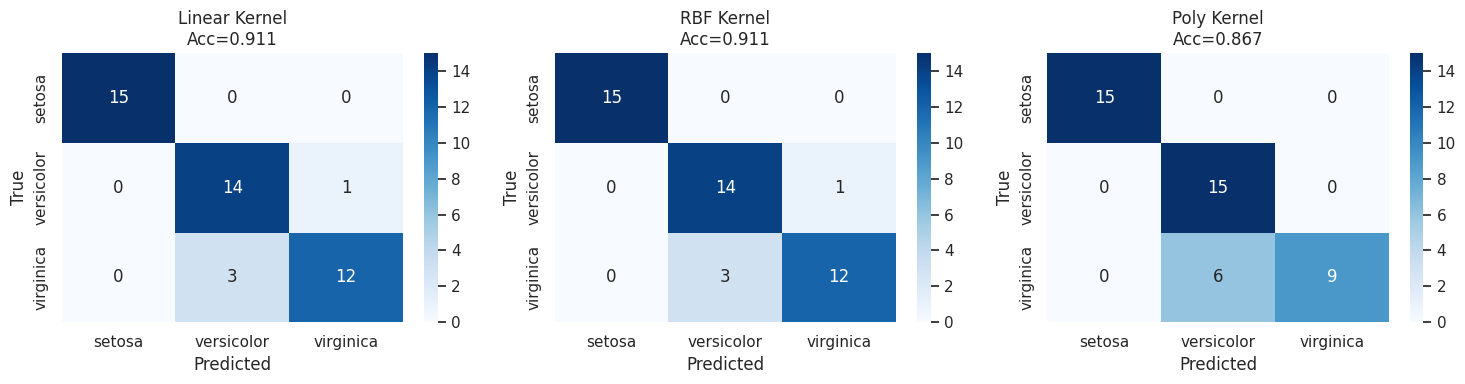

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_linear, y_pred_rbf, y_pred_poly],
    ['Linear Kernel', 'RBF Kernel', 'Poly Kernel']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(f'{title}\nAcc={accuracy_score(y_test, y_pred):.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('/tmp/iris_cm.png', dpi=150)
plt.show()

## 7. PCA 降维可视化决策边界

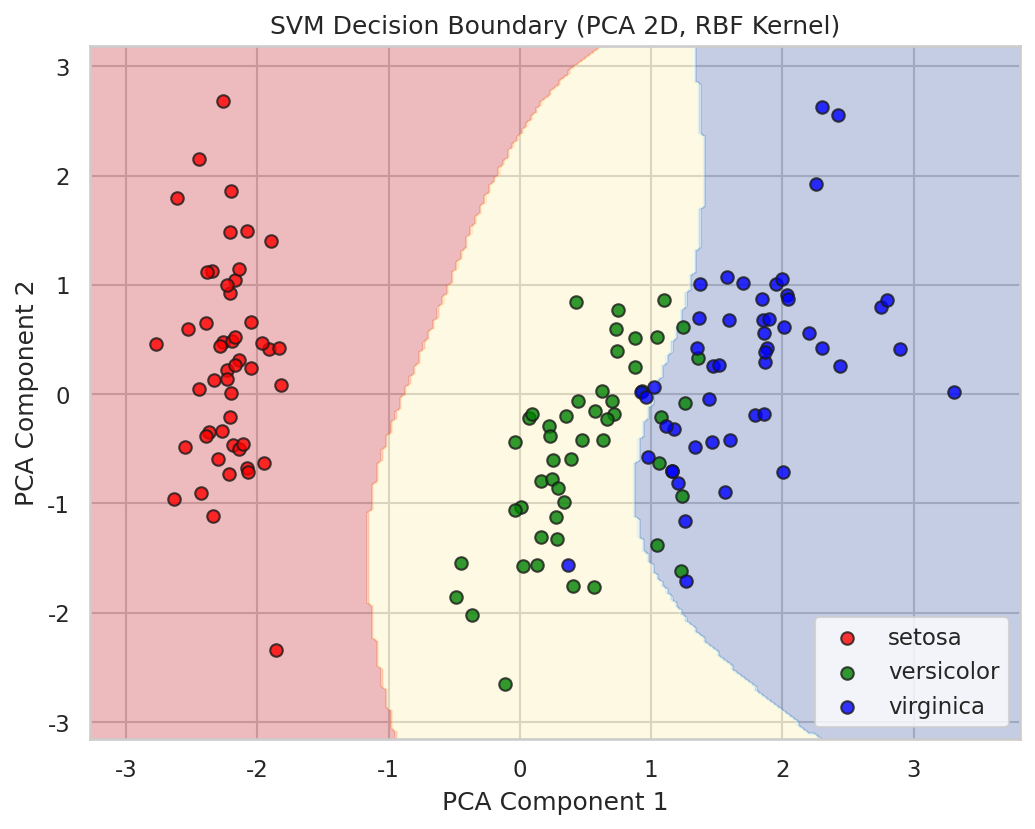

PCA 二维空间 RBF SVM 测试准确率: 0.9111


In [10]:
# 用 PCA 降至 2 维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 在 PCA 空间上重新训练 RBF SVM
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)

svm_2d = svm.SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_2d.fit(X_train_pca, y_train_pca)

# 绘制决策边界
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6), dpi=150)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
colors = ['red', 'green', 'blue']
for i, target_name in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                c=colors[i], label=target_name, edgecolors='k', alpha=0.8)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('SVM Decision Boundary (PCA 2D, RBF Kernel)')
plt.legend()
plt.savefig('/tmp/iris_decision.png', dpi=150)
plt.show()

print(f'PCA 二维空间 RBF SVM 测试准确率: {svm_2d.score(X_test_pca, y_test_pca):.4f}')

## 8. 结果汇总

In [11]:
print('='*50)
print('Iris 数据集 SVM 分类结果汇总')
print('='*50)
print(f'Linear Kernel 准确率: {acc_linear:.4f}')
print(f'RBF Kernel    准确率: {acc_rbf:.4f}')
print(f'Poly Kernel   准确率: {acc_poly:.4f}')
print(f'GridSearchCV  最佳:  {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  最佳参数: {grid_search.best_params_}')
print('='*50)

Iris 数据集 SVM 分类结果汇总
Linear Kernel 准确率: 0.9111
RBF Kernel    准确率: 0.9111
Poly Kernel   准确率: 0.8667
GridSearchCV  最佳:  0.9111
  最佳参数: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
